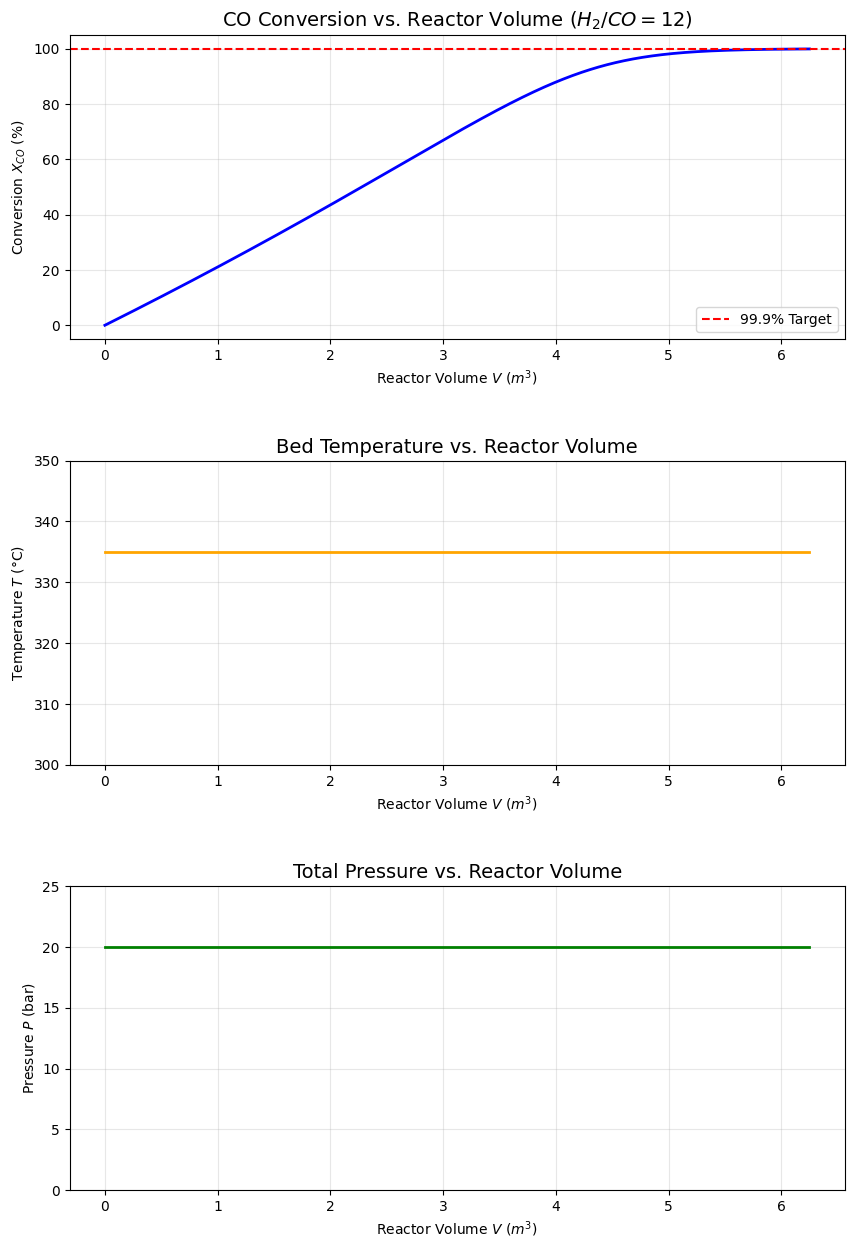

Final Reactor Volume for 99.9% Conversion: 6.25 m³


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =================================================================
# 1. KINETIC PARAMETERS (Yates & Satterfield, 1991)
# =================================================================
A0 = 8.88522e-3    # mol/s/kg_cat/bar²
EA = 3.737e4       # Activation energy J/mol
B0 = 2.226         # bar⁻¹
DBH = -6.837e3     # Adsorption enthalpy J/mol
T0 = 493.15        # Reference T [K]
RU = 8.314         # Gas constant J/mol/K
F_ACTIVITY = 3.0   # Catalyst activity factor

def get_kinetics(T):
    """Calculate T-dependent rate (a) and adsorption (b) coefficients."""
    # a = A0 * exp((EA/RU) * (1/T0 - 1/T))
    a = A0 * np.exp((EA / RU) * (1.0 / T0 - 1.0 / T))
    # b = B0 * exp((DBH/RU) * (1/T0 - 1/T))
    b = B0 * np.exp((DBH / RU) * (1.0 / T0 - 1.0 / T))
    return a, b

# =================================================================
# 2. REACTOR & FEED SPECIFICATIONS
# =================================================================
T_BED = 335.0 + 273.15    # Isothermal bed temperature [K]
P_TOTAL = 20.0            # Total pressure [bar]
ETA = 0.90                # Effectiveness factor
EPSILON = 0.55            # Bed voidage
RHO_P = 1800.0            # Particle density [kg/m³]

# Bulk catalyst density [kg_cat / m³_reactor]
RHO_CAT_BULK = RHO_P * (1.0 - EPSILON) * ETA 

# Feed conditions
N_CO_IN = 1239.6          # CO feed [mol/s]
H2_CO_RATIO = 12.0        # Updated feed ratio H2/CO = 12
N_H2_IN = N_CO_IN * H2_CO_RATIO
N_TOT_IN = N_CO_IN + N_H2_IN

# Stoichiometry: CO + 2H2 -> -CH2- + H2O
# Change in moles (Delta n) = -1 per mol CO
NU = np.array([-1.0, -2.0, +1.0, +1.0]) 

def dF_dV(V, F):
    """ODE: dF/dV = NU * r_V"""
    F_tot = np.sum(F)
    if F_tot <= 0: return np.zeros(4)
    
    # Partial pressures from mole fractions
    p_CO = (F[0] / F_tot) * P_TOTAL
    p_H2 = (F[1] / F_tot) * P_TOTAL
    
    a, b = get_kinetics(T_BED)
    # Volumetric rate r_V [mol_CO/s/m³_reactor]
    r_intrinsic = F_ACTIVITY * a * p_CO * p_H2 / (1.0 + b * p_CO)**2
    r_V = r_intrinsic * RHO_CAT_BULK
    
    return NU * r_V

# =================================================================
# 3. SIMULATION EXECUTION
# =================================================================
def run_simulation(X_target=0.999, V_limit=25000.0):
    F0 = np.array([N_CO_IN, N_H2_IN, 0.0, 0.0])
    
    # Event to stop at target conversion
    def target_reached(V, F):
        current_X = (N_CO_IN - F[0]) / N_CO_IN
        return current_X - X_target
    target_reached.terminal = True
    target_reached.direction = 1

    sol = solve_ivp(dF_dV, (0, V_limit), F0, events=target_reached, 
                    rtol=1e-8, atol=1e-10, dense_output=True)
    
    V_final = sol.t_events[0][0] if sol.t_events[0].size > 0 else V_limit
    V_arr = np.linspace(0, V_final, 1000)
    F_arr = sol.sol(V_arr)
    X_arr = (N_CO_IN - F_arr[0]) / N_CO_IN
    
    return V_arr, X_arr, F_arr

V, X, F = run_simulation()

# =================================================================
# 4. PLOTTING RESULTS
# =================================================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))
plt.subplots_adjust(hspace=0.4)

# Plot 1: Conversion vs Volume
ax1.plot(V, X * 100, color='blue', linewidth=2)
ax1.set_title('CO Conversion vs. Reactor Volume ($H_2/CO=12$)', fontsize=14)
ax1.set_xlabel('Reactor Volume $V$ ($m^3$)')
ax1.set_ylabel('Conversion $X_{CO}$ (%)')
ax1.grid(True, alpha=0.3)
ax1.axhline(99.9, color='red', linestyle='--', label='99.9% Target')
ax1.legend()

# Plot 2: Temperature vs Volume (Isothermal assumption)
# Current model assumes T is constant throughout the bed
T_Celsius = np.full_like(V, T_BED - 273.15)
ax2.plot(V, T_Celsius, color='orange', linewidth=2)
ax2.set_title('Bed Temperature vs. Reactor Volume', fontsize=14)
ax2.set_xlabel('Reactor Volume $V$ ($m^3$)')
ax2.set_ylabel('Temperature $T$ (°C)')
ax2.set_ylim(300, 350)
ax2.grid(True, alpha=0.3)

# Plot 3: Pressure vs Volume (Isobaric assumption)
# Current model assumes constant total pressure
P_arr = np.full_like(V, P_TOTAL)
ax3.plot(V, P_arr, color='green', linewidth=2)
ax3.set_title('Total Pressure vs. Reactor Volume', fontsize=14)
ax3.set_xlabel('Reactor Volume $V$ ($m^3$)')
ax3.set_ylabel('Pressure $P$ (bar)')
ax3.set_ylim(0, 25)
ax3.grid(True, alpha=0.3)

plt.show()

# Final Design Output
print(f"Final Reactor Volume for 99.9% Conversion: {V[-1]:.2f} m³")